**Using PINNs to find out how long it takes for a beer (or non-alcoholic, for those who prefer so :)) bottle to cool down in a fridge**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [ ]:
# Modelling the bottle as an infinitely long (not true, but whatever, I want to stick to 2 spatial dimensions) cylinder of radius R
# It sits in the fridge with no convective heat trasnfer, just constant temperature at the boundary (4 C)
# Goal: understand when the average temperature of the bottle cools down to a target temperature (say 6 C)
# simple heat equation with Dirichlet boundary conditions, no recirculations inside the bottle

bottle_radius = 0.03
target_temperature = 6
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water

#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle(R = bottle_radius)

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_19461/2014291051.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')


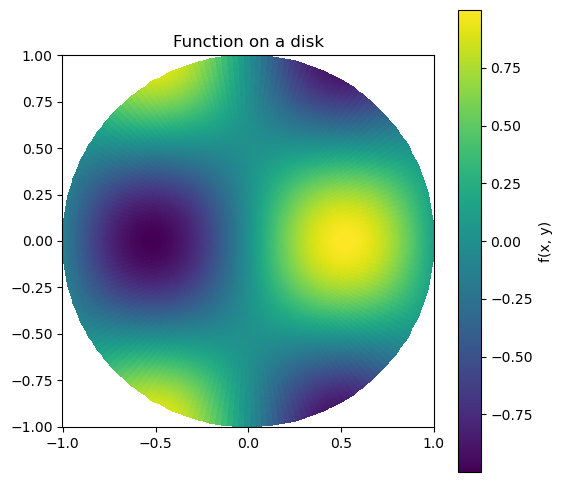

In [3]:
# test to plot functions on a circle

def f(x, y):
    return np.sin(3*x) * np.cos(3*y)  # your function here

radius = 1.0
N_r, N_theta = 200, 200

r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax, label='f(x, y)')
ax.set_title('Function on a disk')
plt.show()